In [16]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D

In [17]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

#### It contains : 0 to 9 handwritten digits

#### Training set = 60,000 images
#### Test set = 10,000 images

In [18]:
print(f"Shape of X_train :{X_train.shape}") 
print(f"Shape of X_test :{X_test.shape}")
print(f"Shape of y_train :{y_train.shape}")
print(f"Shape of y_test:{y_test.shape}")

Shape of X_train :(60000, 28, 28)
Shape of X_test :(10000, 28, 28)
Shape of y_train :(60000,)
Shape of y_test:(10000,)


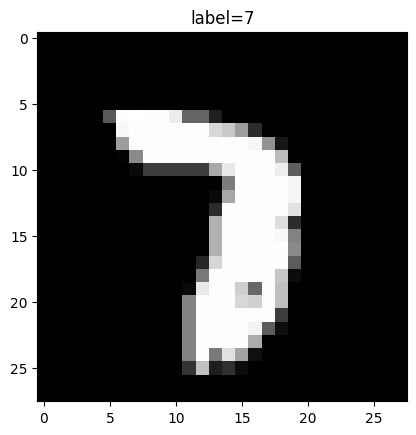

In [19]:
plt.imshow(X_train[1400],cmap="grey")
plt.title(f"label={y_train[1400]}")
plt.show()

In [20]:
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

In [22]:
model = Sequential()

model.add(Conv2D(128,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(2,2),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(32,(2,2),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(100,activation='relu'))

model.add(Dense(50,activation='relu'))

model.add(Dense(10,activation='softmax'))

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,156 (234.98 KB)

 Trainable params: 60,156 (234.98 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9156 - loss: 0.3137 - val_accuracy: 0.9660 - val_loss: 0.1135
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9677 - loss: 0.1057 - val_accuracy: 0.9766 - val_loss: 0.0813
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9743 - loss: 0.0826 - val_accuracy: 0.9707 - val_loss: 0.1022
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9782 - loss: 0.0696 - val_accuracy: 0.9782 - val_loss: 0.0752
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.9817 - loss: 0.0590 - val_accuracy: 0.9819 - val_loss: 0.0596
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.9802 - val_loss: 0.0663
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9852 - loss: 0.0477 - val_accuracy: 0.9809 - val_loss: 0.0688
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9871 -

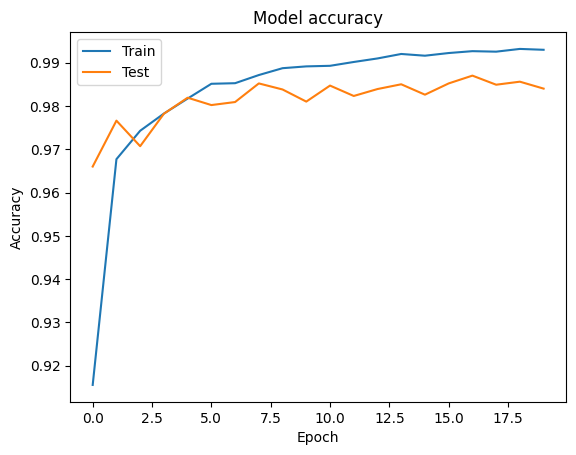

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

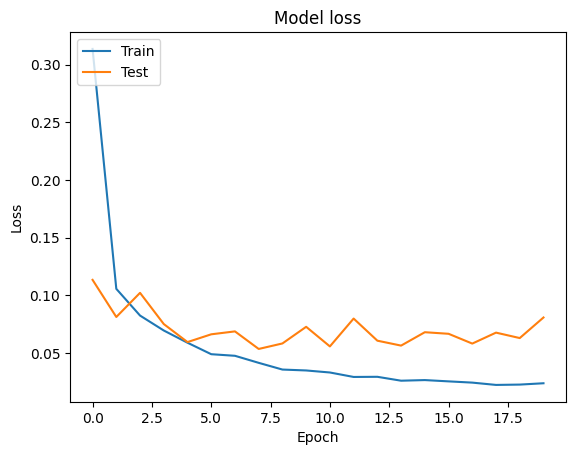

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

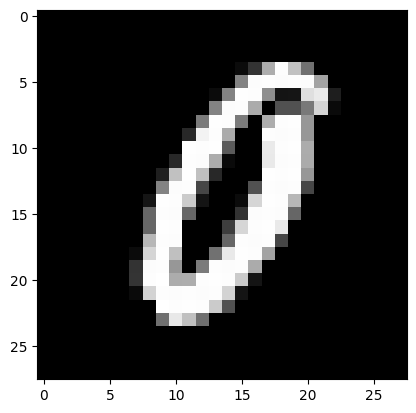

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted digit: 0
Actual digit: 0


In [30]:
import numpy as np

index = 1288
image = X_test[index]


plt.imshow(image.reshape(28, 28), cmap='gray')
plt.show()

image_input = image.reshape(1, 28, 28, 1)


prediction = model.predict(image_input)

print("Predicted digit:", np.argmax(prediction))
print("Actual digit:", y_test[index])